In [1]:
pwd

'/workspace'

In [16]:
!git clone https://github.com/ultralytics/ultralytics.git


Cloning into 'ultralytics'...
remote: Enumerating objects: 76052, done.
remote: Counting objects: 100% (328/328), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 76052 (delta 252), reused 184 (delta 166), pack-reused 75724 (from 3)
Receiving objects: 100% (76052/76052), 40.63 MiB | 17.70 MiB/s, done.
Resolving deltas: 100% (57146/57146), done.


In [17]:
%cd ultralytics
!pip install -e .


/workspace/ultralytics


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.13a0+0d33366-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 

In [6]:
!pip install "numpy<2" --force-reinstall


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.13a0+0d33366-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 

In [1]:
import numpy as np
np.__version__


'1.26.4'

In [1]:
import os
import sys

#  Set the working directory to the folder containing the top-level ultralytics package
os.chdir("/workspace")  # change to your workspace root where ultralytics folder exists
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [2]:
#  Add the top-level ultralytics folder to Python path
os.chdir("/workspace/ultralytics")
print("Current working directory:", os.getcwd())

Current working directory: /workspace/ultralytics


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
Setup complete ✅ (224 CPUs, 2015.6 GB RAM, 621.5/3515.6 GB disk)


In [4]:
from ultralytics import YOLO

# -------------------------------
# Load YAML (with original SPPF)
# -------------------------------
model = YOLO('yolov8.yaml')
print("Original model loaded ")


WARNING ⚠️ no model scale passed. Assuming scale='n'.
Original model loaded 


In [5]:
import ultralytics
print(ultralytics.__file__)


/workspace/ultralytics/ultralytics/__init__.py


In [6]:
from ultralytics.models.yolo.model import YOLO

# Load your YOLOv8 model
model = YOLO("ultralytics/cfg/models/v8/yolov8.yaml")

# Print the full architecture
print(model.model)   # model.model contains the actual PyTorch nn.Module


WARNING ⚠️ no model scale passed. Assuming scale='n'.
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stat

In [7]:
print("Current working directory:", os.getcwd())


Current working directory: /workspace/ultralytics


In [8]:
from ultralytics import YOLO
import time
import torch

# ------------------- Parameters -------------------
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
run_name = "yolov8n_idd_adamw_ciou"
epochs = 1
imgsz = 640
batch_size = 64
workers = 8
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cache_images = "disk"
amp = True
save_interval = 50
patience = 20

# ------------------- Load Model -------------------
model = YOLO("yolov8n.pt")    # pretrained COCO weights

# ------------------- Training -------------------
start_time = time.time()
print(f"Starting training for {epochs} epochs...\n")

results = model.train(
    data=dataset_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    workers=workers,
    device=device,
    cache=cache_images,
    name=run_name,
    save=True,
    amp=amp,
    patience=patience,
    save_period=save_interval,

    # AdamW hyperparameters
    optimizer="AdamW",
    lr0=0.001,                 # base learning rate
    weight_decay=0.0001,       # AdamW-style decay

    # LR scheduling
    cos_lr=True,               # Cosine annealing
    lrf=0.01,                  # final LR factor (LR_min = lr0*lrf)

    # Training augmentations
    augment=True
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")


Starting training for 1 epochs...

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/datasets/IDD_YOLO/idd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_idd_adamw_ciou, nbs=64, nms=False, opset=None, optimi

In [9]:
from ultralytics import YOLO
import time
import torch

# ------------------- Parameters -------------------
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
run_name = "yolov8n_idd_adamw_ciou"
epochs = 150
imgsz = 640
batch_size = 64
workers = 8
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cache_images = "disk"
amp = True
save_interval = 50
patience = 20

# ------------------- Load Model -------------------
model = YOLO("yolov8n.pt")    # pretrained COCO weights

# ------------------- Training -------------------
start_time = time.time()
print(f"Starting training for {epochs} epochs...\n")

results = model.train(
    data=dataset_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    workers=workers,
    device=device,
    cache=cache_images,
    name=run_name,
    save=True,
    amp=amp,
    patience=patience,
    save_period=save_interval,

    # AdamW hyperparameters
    optimizer="AdamW",
    lr0=0.001,                 # base learning rate
    weight_decay=0.0001,       # AdamW-style decay

    # LR scheduling
    cos_lr=True,               # Cosine annealing
    lrf=0.01,                  # final LR factor (LR_min = lr0*lrf)

    # Training augmentations
    augment=True
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")


Starting training for 150 epochs...

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/datasets/IDD_YOLO/idd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_idd_adamw_ciou, nbs=64, nms=False, opset=None, op

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [6]:
from ultralytics import YOLO
import torch
import time

# ------------------- Paths -------------------
weights = "/workspace/ultralytics/runs/detect/yolov8n_idd_adamw_ciou/weights/best.pt"
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
results_dir = "/workspace/idd_validation"

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# ------------------- Load model -------------------
model = YOLO(weights)

# ------------------- Run Validation -------------------
print("Running validation...")

start = time.time()

model.val(
    data=dataset_yaml,
    imgsz=640,
    batch=64,
    device=device,
    project=results_dir,
    name="idd_evalv8n_ciou_adamw",
    save_json=True,
    exist_ok=True,
    verbose=True
)

end = time.time()
print(f"\nValidation completed in {end - start:.2f} seconds")
print(f"Results saved in {results_dir}/idd_eval/")


Running validation...
Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1533.1±417.3 MB/s, size: 413.2 KB)

val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-02-50_0004247.jpg: 1 duplicate labels removed
val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-22-50_0007776.jpg: 1 duplicate labels removed
val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-22-50_0008384.jpg: 1 duplicate labels removed

                   all      10225     119936      0.683      0.415      0.464      0.297
                person       5047      18078      0.725      0.396      0.463      0.257
                 rider       6130      24517      0.759      0.458      0.523      0.303
                   car       6592      24843   


image 1/1 /workspace/0000240.jpg: 384x640 1 person, 5 cars, 35.5ms
Speed: 2.0ms preprocess, 35.5ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


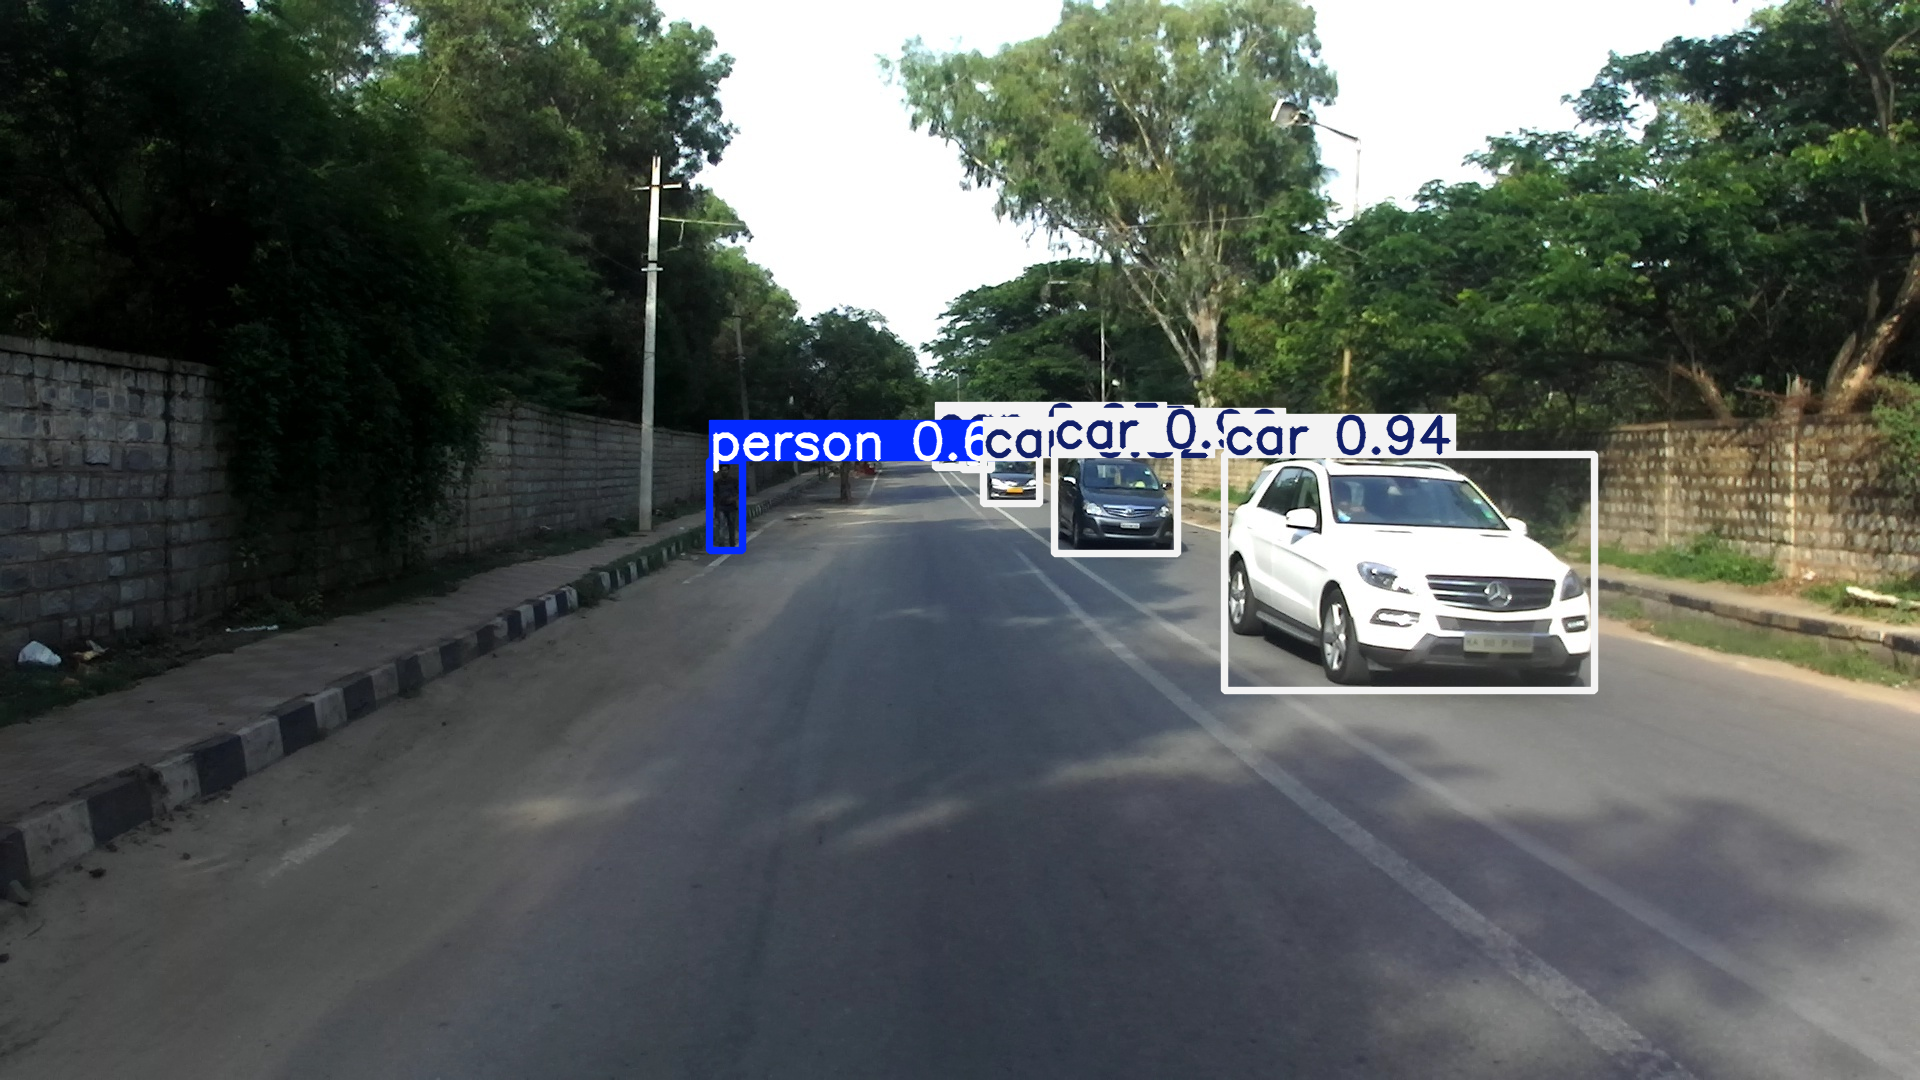

In [4]:
from ultralytics import YOLO

# Try loading and running inference with the trained model
model = YOLO("/workspace/ultralytics/runs/detect/yolov8n_idd_adamw_ciou/weights/best.pt")  # path to your trained model
results = model.predict("/workspace/0000240.jpg")  # use any sample image
results[0].show()


In [5]:
import numpy as np
import pandas as pd

class_names = [
    "person", "rider", "car", "truck", "bus",
    "motorcycle", "bicycle", "autorickshaw",
    "animal", "traffic light", "traffic sign"
]

conf_matrix = np.array([
    [7023,272,104,0,38,2,4,26,0,3,1840],
    [378,10919,115,7,0,150,1,26,2,4,2423],
    [14,64,14128,160,120,63,0,124,0,2,3085],
    [0,3,85,3634,247,3,0,196,0,6,1027],
    [0,0,97,158,2870,0,0,7,0,1,619],
    [120,194,147,4,1,14208,71,9,9,0,3201],
    [3,0,0,6,31,0,159,0,2,0,94],
    [11,25,102,180,13,7,0,4479,2,0,910],
    [2,0,0,0,0,1,0,0,221,1,108],
    [0,0,0,0,0,0,0,0,0,126,80],
    [2,1,2,1,0,1,0,0,0,9,1039]
])

per_class_precision = [0.725,0.759,0.765,0.693,0.758,0.771,0.546,0.769,0.614,0.556,0.551]
per_class_recall    = [0.396,0.458,0.572,0.535,0.602,0.568,0.306,0.589,0.154,0.140,0.246]
per_class_map50     = [0.463,0.523,0.636,0.588,0.662,0.623,0.329,0.650,0.195,0.165,0.265]
per_class_map5095   = [0.257,0.303,0.446,0.421,0.505,0.374,0.189,0.465,0.0946,0.076,0.139]

metrics_data = []
total_samples = np.sum(conf_matrix)

for i, cname in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[i, :]) - TP
    FN = np.sum(conf_matrix[:, i]) - TP
    TN = total_samples - (TP + FP + FN)

    P = per_class_precision[i]
    R = per_class_recall[i]
    F1 = 2 * P * R / (P + R) if (P + R) else 0

    metrics_data.append({
        "Class": cname,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "Precision": round(P,4),
        "Recall": round(R,4),
        "F1 Score": round(F1,4),
        "Accuracy": round((TP+TN)/total_samples,4),
        "FPR": round(FP/(FP+TN),4),
        "FNR": round(FN/(FN+TP),4),
        "mAP@0.5": per_class_map50[i],
        "mAP@0.5:0.95": per_class_map5095[i]
    })

# -----------------------------
# OVERALL ROW
# -----------------------------
overall = {
    "Class": "Overall",
    "TP": sum(r["TP"] for r in metrics_data),
    "FP": sum(r["FP"] for r in metrics_data),
    "FN": sum(r["FN"] for r in metrics_data),
    "TN": sum(r["TN"] for r in metrics_data),
    "Precision": round(np.mean([r["Precision"] for r in metrics_data]),4),
    "Recall": round(np.mean([r["Recall"] for r in metrics_data]),4),
    "F1 Score": round(np.mean([r["F1 Score"] for r in metrics_data]),4),
    "Accuracy": round(np.mean([r["Accuracy"] for r in metrics_data]),4),
    "FPR": round(np.mean([r["FPR"] for r in metrics_data]),4),
    "FNR": round(np.mean([r["FNR"] for r in metrics_data]),4),
    "mAP@0.5": round(np.mean(per_class_map50),4),
    "mAP@0.5:0.95": round(np.mean(per_class_map5095),4)
}

metrics_data.append(overall)

df = pd.DataFrame(metrics_data)
df.to_csv("idd_metrics_v8nciouadamw.csv", index=False)
print(df)


            Class     TP     FP     FN      TN  Precision  Recall  F1 Score  \
0          person   7023   2289    530   65790     0.7250  0.3960    0.5122   
1           rider  10919   3106    559   61048     0.7590  0.4580    0.5713   
2             car  14128   3632    652   57220     0.7650  0.5720    0.6546   
3           truck   3634   1567    516   69915     0.6930  0.5350    0.6038   
4             bus   2870    882    450   71430     0.7580  0.6020    0.6711   
5      motorcycle  14208   3756    227   57441     0.7710  0.5680    0.6541   
6         bicycle    159    136     76   75261     0.5460  0.3060    0.3922   
7    autorickshaw   4479   1250    388   69515     0.7690  0.5890    0.6671   
8          animal    221    112     15   75284     0.6140  0.1540    0.2462   
9   traffic light    126     80     26   75400     0.5560  0.1400    0.2237   
10   traffic sign   1039     16  13387   61190     0.5510  0.2460    0.3401   
11        Overall  58806  16826  16826  739494     0

In [10]:
# ==============================================================
# YOLOv8 Speed Benchmark (H100 / MIG Safe)
# Resolution: 640 x 640
# Batch size: 1
# Metrics:
#   - Pure Inference Time (ms/frame)
#   - Inference FPS
#   - End-to-End Latency (ms/frame)
#   - Latency FPS
#   - Model Parameters (M)
#   - Model File Size (MB)
# ==============================================================

import torch
import cv2
import csv
import os
from pathlib import Path
from ultralytics import YOLO

# -----------------------------
# CONFIGURATION
# -----------------------------
weights = "/workspace/ultralytics/runs/detect/yolov8n_idd_adamw_ciou/weights/best.pt"          # Path to trained YOLOv8 model
img_path = "/workspace/0000240.jpg"      # Any validation image
img_size = 640
batch_size = 1
csv_file = "benchmark_results_v8nciouadamw.csv"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------
# DEVICE INFO
# -----------------------------
print(f"\nUsing device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}\n")

# -----------------------------
# LOAD MODEL
# -----------------------------
model = YOLO(weights).to(device)
model.model.eval()

model_name = Path(weights).stem
model_size_mb = Path(weights).stat().st_size / (1024 ** 2)

params = sum(p.numel() for p in model.model.parameters())
params_million = params / 1e6

print(f"Model: {model_name}")
print(f"Parameters: {params_million:.2f} M")
print(f"Model file size: {model_size_mb:.2f} MB\n")

# ==============================================================
# 1️ PURE INFERENCE SPEED (FORWARD PASS ONLY)
# ==============================================================

dummy_input = torch.randn(
    batch_size, 3, img_size, img_size, device=device
) / 255.0

# Warm-up
for _ in range(10):
    _ = model.model(dummy_input)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

n_runs = 100

starter.record()
with torch.inference_mode():
    for _ in range(n_runs):
        _ = model.model(dummy_input)
ender.record()

torch.cuda.synchronize()

inference_time_ms = starter.elapsed_time(ender) / n_runs
inference_fps = 1000 / inference_time_ms

print("=== Pure Inference (Forward Pass Only) ===")
print(f"Inference Time:  {inference_time_ms:.2f} ms/frame")
print(f"Inference Speed: {inference_fps:.2f} FPS @ {img_size}x{img_size}\n")

# ==============================================================
# 2️ END-TO-END LATENCY (PRE + INFER + POST)
# ==============================================================

img = cv2.imread(img_path)
assert img is not None, "Failed to load image."

# Warm-up
for _ in range(5):
    _ = model.predict(
        img, imgsz=img_size, device=device, verbose=False
    )

torch.cuda.synchronize()

starter.record()
for _ in range(30):
    _ = model.predict(
        img, imgsz=img_size, device=device, verbose=False
    )
ender.record()

torch.cuda.synchronize()

latency_ms = starter.elapsed_time(ender) / 30
latency_fps = 1000 / latency_ms

print("=== End-to-End Latency (Full Pipeline) ===")
print(f"Latency:     {latency_ms:.2f} ms/frame")
print(f"Latency FPS:{latency_fps:.2f}\n")

# ==============================================================
# 3️ SAVE RESULTS TO CSV
# ==============================================================

fieldnames = [
    "Model",
    "GPU",
    "Batch_Size",
    "Image_Size",
    "Params_(M)",
    "Model_Size_(MB)",
    "Inference_Time_(ms)",
    "Inference_FPS",
    "Latency_(ms)",
    "Latency_FPS",
]

file_exists = os.path.isfile(csv_file)

with open(csv_file, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    writer.writerow({
        "Model": model_name,
        "GPU": torch.cuda.get_device_name(0),
        "Batch_Size": batch_size,
        "Image_Size": f"{img_size}x{img_size}",
        "Params_(M)": round(params_million, 2),
        "Model_Size_(MB)": round(model_size_mb, 2),
        "Inference_Time_(ms)": round(inference_time_ms, 2),
        "Inference_FPS": round(inference_fps, 2),
        "Latency_(ms)": round(latency_ms, 2),
        "Latency_FPS": round(latency_fps, 2),
    })

print(f"Benchmark results saved to: {csv_file}")

# ==============================================================
# SUMMARY
# ==============================================================
print("\n=== Benchmark Summary ===")
print(f"Model:            {model_name}")
print(f"GPU:              {torch.cuda.get_device_name(0)} (MIG Enabled)")
print(f"Input Resolution: {img_size}x{img_size}")
print(f"Batch Size:       {batch_size}")
print(f"Parameters:       {params_million:.2f} M")
print(f"Model Size:       {model_size_mb:.2f} MB")
print(f"Inference Time:   {inference_time_ms:.2f} ms ({inference_fps:.2f} FPS)")
print(f"Latency:          {latency_ms:.2f} ms ({latency_fps:.2f} FPS)")
print("=============================================================")



Using device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
CUDA Version: 12.6
cuDNN Version: 90600

Model: best
Parameters: 3.01 M
Model file size: 5.96 MB

=== Pure Inference (Forward Pass Only) ===
Inference Time:  2.70 ms/frame
Inference Speed: 369.95 FPS @ 640x640

=== End-to-End Latency (Full Pipeline) ===
Latency:     5.30 ms/frame
Latency FPS:188.56

Benchmark results saved to: benchmark_results_v8nciouadamw.csv

=== Benchmark Summary ===
Model:            best
GPU:              NVIDIA H100 80GB HBM3 MIG 3g.40gb (MIG Enabled)
Input Resolution: 640x640
Batch Size:       1
Parameters:       3.01 M
Model Size:       5.96 MB
Inference Time:   2.70 ms (369.95 FPS)
Latency:          5.30 ms (188.56 FPS)
